# Q1 Momentum Backtester Framework  
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom backtesting framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework allows you to test trading strategies against historical market data to evaluate their performance before risking real capital.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential drawdowns and volatility
- Performance comparison: Benchmark your strategy against market indices
- Flexibility: Custom-built framework allows for complete control over testing parameters

This framework provides a solid foundation for quantitative trading strategy development and evaluation.

## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for assets like AAPL and SPY
    - Stores processed data for efficient reuse

2. Signal Generation - moving average crossovers were chosen for their simplicity and interpretability, making them ideal for a baseline strategy.
    - Implements strategy logic, including momentum-based approaches
    - Generates trading signals indexed by days
    - Supports staged entry and exit logic based on rolling averages  

3. Backtesting Engine
    - Simulates portfolio evolution with precise cash and position tracking
    - Handles trade execution based on generated signals
    - Manages multiple positions and cash balance throughout the simulation  

4. Performance Analysis
    - Measures performance using multiple meaningful metrics:
        - Returns (absolute and relative)
        - Risk-adjusted metrics (Sharpe ratio)
        - Drawdown analysis (maximum drawdown)
        - Trading statistics (win rate)
    - Compares strategy performance against benchmark indices  

5. Visualisation
    - Displays equity curves to track portfolio growth
    - Shows drawdown charts to visualise risk periods
    - Provides comparative performance visualisations against benchmarks  

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns


import sys
sys.path.append('../utils')   # path relative to the notebook
from Q1_functions import add_signals, run_backtest, compute_metrics, plot_performance
from common import fetch_data

## 3. Signal Generation

The first thing to do is to download the historical data for a given time period, then clean it to remove incomplete values and keep only the relevant columns.  
This is done by the function `fetch_data()`.

Subsequently, we calculate the moving average for 20 and 50 days, from which we find the points where MA20 goes over MA50 and vice versa, which are commonly known as the "golden cross" and "death cross", respectively.  
This is done by the function `add_signals()`.

In [2]:
# Load data
starting_capital = 10_000
period = 10
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

dataA = fetch_data('AAPL', start, end)
dataA = add_signals(dataA)

dataS = fetch_data('SPY', start, end)
dataS = add_signals(dataS)

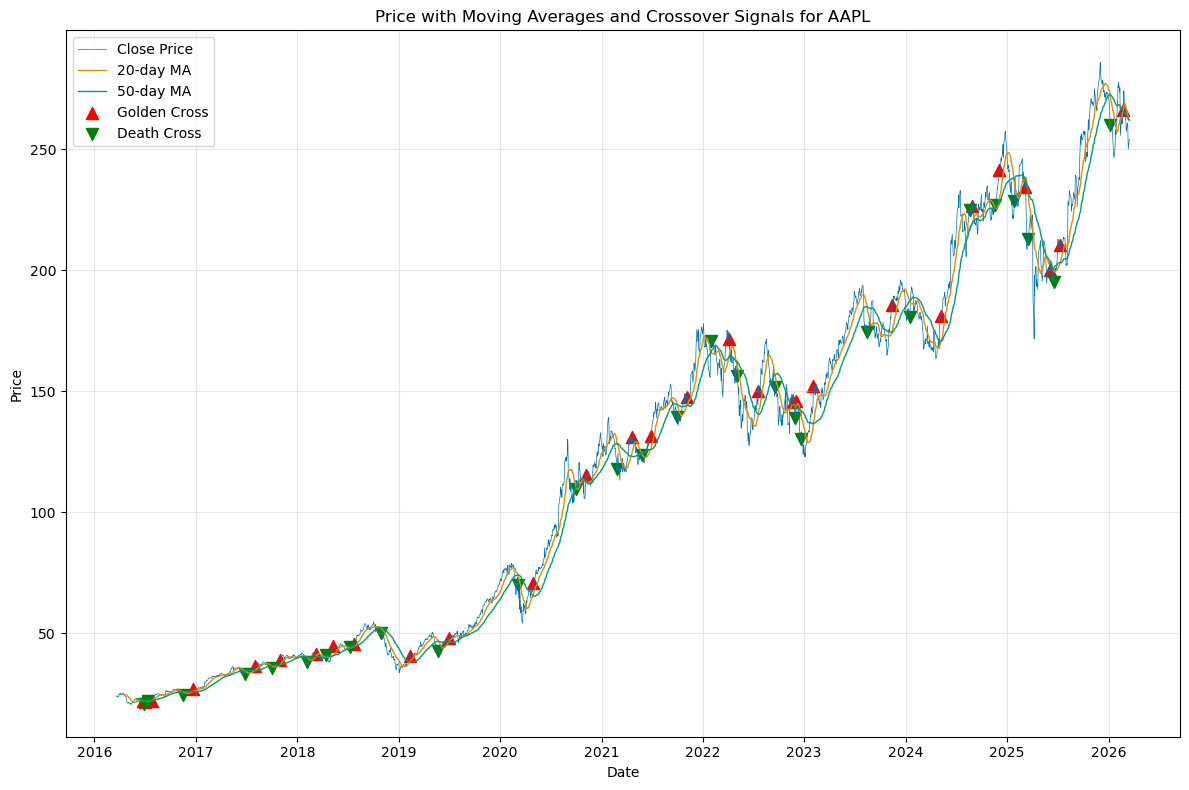

In [3]:
# Visualize the signals to check that the MA and crosses are calöculated correctly
plt.figure(figsize=(12, 8))
colors = sns.color_palette("colorblind")

plt.plot(dataA.index, dataA['Close'], color=colors[0], label='Close Price', linewidth=0.5)
plt.plot(dataA.index, dataA['MA20'], color=colors[1], label='20-day MA', linewidth=1, linestyle='-')
plt.plot(dataA.index, dataA['MA50'], color=colors[2], label='50-day MA', linewidth=1, linestyle='-')

golden_cross_points = dataA[dataA['Golden_Cross']]
death_cross_points = dataA[dataA['Death_Cross']]
plt.scatter(golden_cross_points.index, golden_cross_points['Close'], color='red', s=75, marker='^', label='Golden Cross')
plt.scatter(death_cross_points.index, death_cross_points['Close'], color='green', s=75, marker='v', label='Death Cross')

plt.title('Price with Moving Averages and Crossover Signals for AAPL')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#optional: plottting the buy/sell signals
#plt.figure(figsize=(15, 10))
#colors = sns.color_palette("colorblind")
#plt.subplot(2, 1, 2)
#plt.plot(dataA.index, dataA['Signal'], label='Position (1=Long, 0=Cash)')

#plt.title('Position Based on MA Crossover')
#plt.xlabel('Date')
#plt.ylabel('Signal')
#plt.ylim(-0.1, 1.1)
#plt.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.show()

## 4. Backtesting Engine
Once the data and signals have been prepared, we move on to the backtesting engine, the core of this notebook.  
Here, we implement two strategies:
1. We hold out our initial capital until the first golden cross appears, and we proceed to buy as many shares as possible. Then we hold it until a death cross shows up, where we sell all of our shares. We repeat this strategy until the end of the time period.
2. We invest all of our capital at the beginning, and we hold it until the end.

This is done by the function `run_backtest()`.
- There is an option for strategy 1 in which we buy in tranches. Namely, investing half of our capital when a golden cross appears, and the other half only if the current price is still above MA20 and MA50 10 days after our buy.

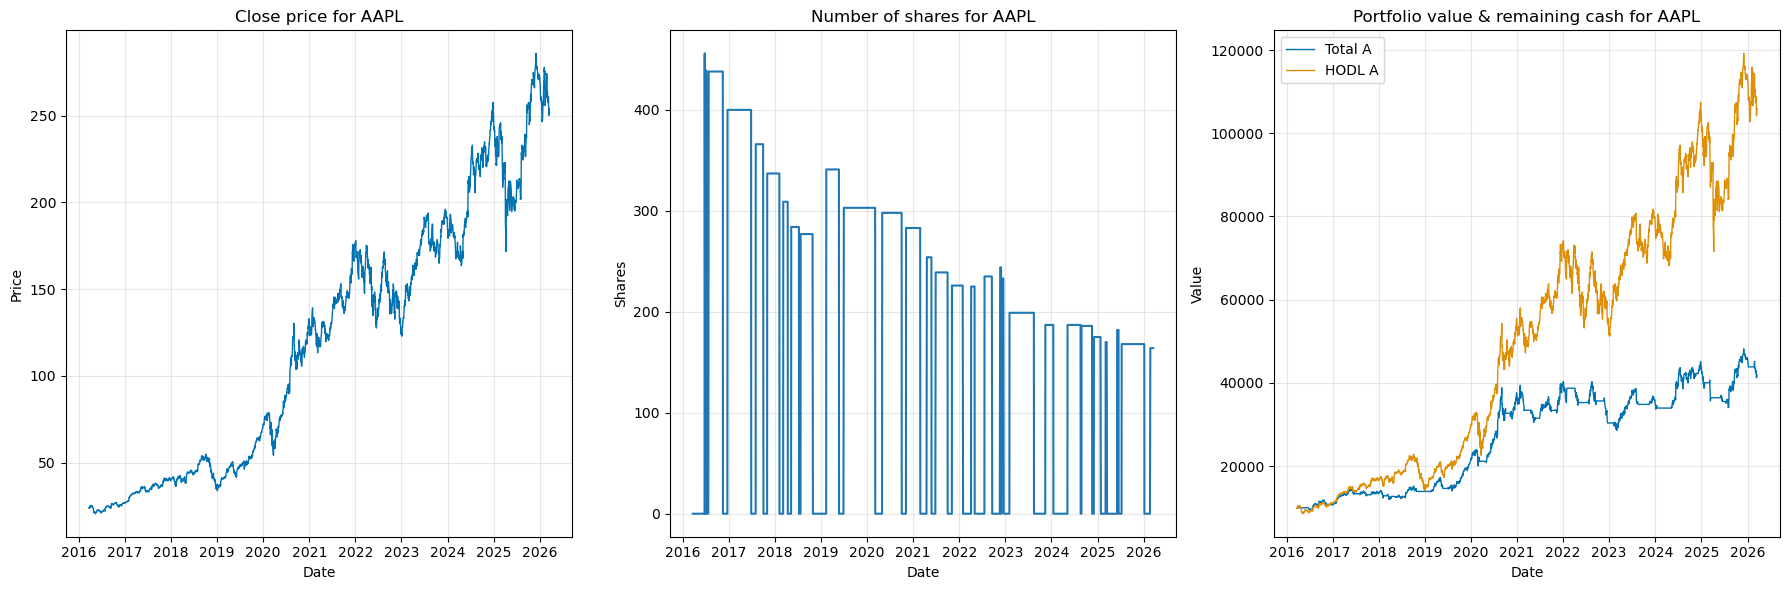

Price,Cash,Portfolio_Value,Shares,Total,Buy_Hold
Date,,,,,
2026-03-11,207.163155,42772.839600,164.0,42980.002754,108731.770233
2026-03-12,207.163155,41944.639099,164.0,42151.802254,106626.422368
2026-03-13,207.163155,41019.679199,164.0,41226.842354,104275.104844
2026-03-16,207.163155,41462.481201,164.0,41669.644356,105400.740784
2026-03-17,207.163155,41693.719299,164.0,41900.882454,105988.565394


In [4]:
dataA = run_backtest(dataA, starting_capital, tranche=False)
dataS = run_backtest(dataS, starting_capital, tranche=False)

plt.figure(figsize=(18, 6))
colors = sns.color_palette("colorblind")

plt.subplot(1, 3, 1)
plt.title('Close price for AAPL')
plt.plot(dataA.index, dataA['Close'], color=colors[0], label='AAPL', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Price')

plt.subplot(1, 3, 2)
plt.title('Number of shares for AAPL')
plt.plot(dataA.index, dataA['Shares'], label='Close Price')
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Shares')

plt.subplot(1, 3, 3)
plt.title('Portfolio value & remaining cash for AAPL')
#plt.plot(dataA.index, dataA['Portfolio_Value'], label='Portfolio_Value', alpha=0.5)
#plt.plot(dataA.index, dataA['Cash'], label='Cash', alpha=0.5)
plt.plot(dataA.index, dataA['Total'], color=colors[0], label='Total A', linewidth=1)
plt.plot(dataA.index, dataA['Buy_Hold'], color=colors[1], label='HODL A', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

display(dataA[['Cash', 'Portfolio_Value', 'Shares', 'Total', 'Buy_Hold']].tail())

## 5. Performance Metrics
After the backtesting is finished and we have calculated our portfolio value, we calculate the most relevant metrics to compare both strategies with each other and to the S&P500 index.  
We calculate the total returns, Sharpe ratio, maximum drawdown, compounding annual growth rate (CAGR), Calmar ratio, and the win rate as single metrics. In addition, we calculate the yearly returns.  
This is done by the function `compute_metrics()`.

In [5]:
dataA, tableA, yearly_dataA = compute_metrics(dataA,starting_capital)
dataS, tableS, yearly_dataS = compute_metrics(dataS,starting_capital)

Last buy still holding.


## 6. Results & Analysis
Finally, we show the results in the form of plots and a table for easier visualization.

The main results are shown as a triple plot:
1. The first one shows the equity curve on a daily basis, in which we compare the total value of our buy/sell strategy against buying and holding the same asset and buying and holding an index.
   - This is important as it shows how much our total portfolio value grows (or drops) in the same time period under different strategies.
2. The second plot shows the drawdowns on a daily basis, where we compare how much our portfolio has dropped in relation to the previous peaks for all three strategies.
    - This is important because it tells us how much our total value fluctuates compared to the other strategies.
3. The last plot shows the annual return, where, as opposed to the total return metric, we show the return for each year.
   - This is important as it shows us if our portfolio has had some negative and positive years, which are not visible in the total return.

A table below shows the comparison of the main metrics for all strategies:
- Total Return
- Sharpe
- Max Drawdown
- CAGR
- Calmar
- Win Rate

This is done by the function  `plot_performance()`.

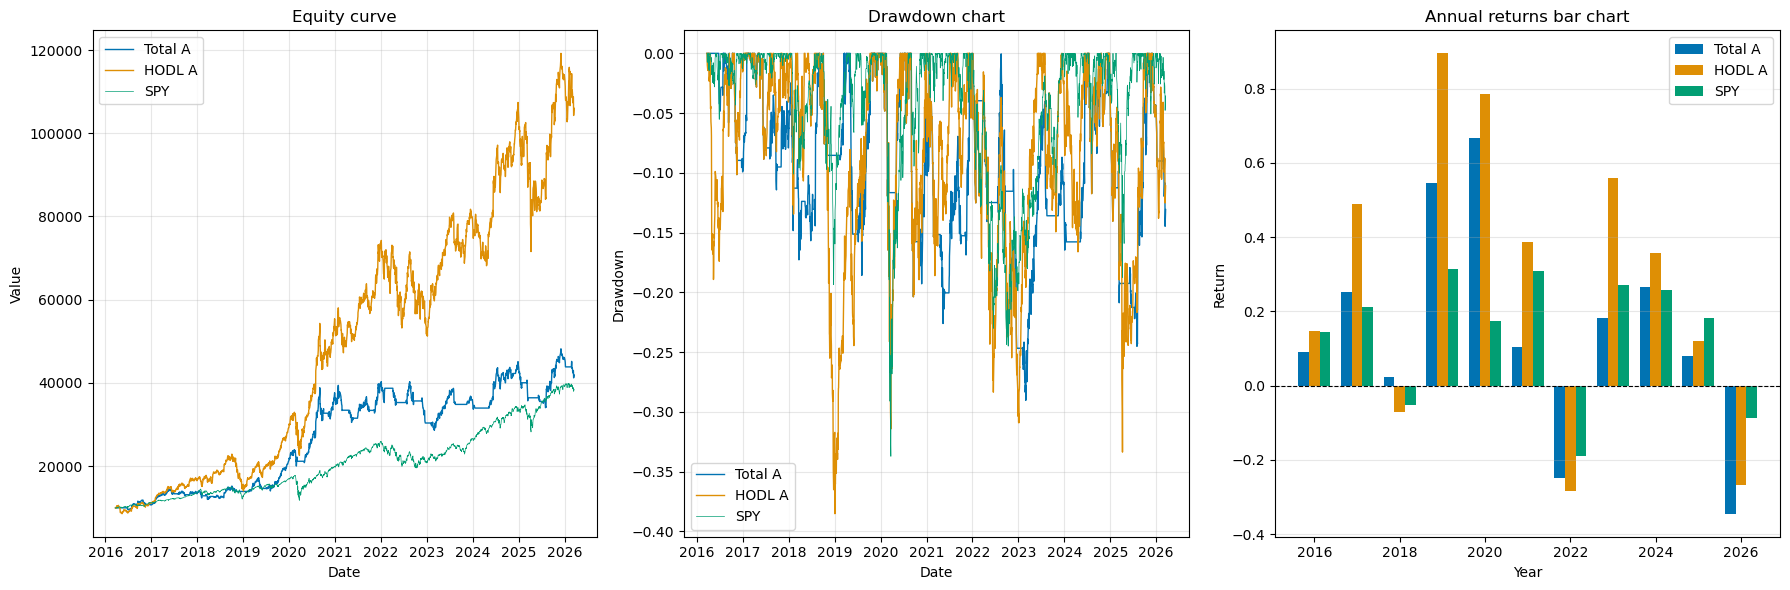

AAPL                 SPY          
              Buy Sell  Buy Hold  Buy Sell  Buy Hold
Total Return  3.190088  9.598857  1.281407  2.847147
Sharpe        0.520034  0.681327  0.374332  0.531401
Max Drawdown -0.290292 -0.385159 -0.286512 -0.337173
CAGR          0.154248  0.266638  0.086087  0.144422
Calmar       -0.531354 -0.692279 -0.300464 -0.428331
Win Rate      0.535714  1.000000  0.666667  1.000000

In [6]:
plot_performance(dataA,dataS,yearly_dataA,yearly_dataS)
display(pd.concat([tableA, tableS], axis=1, keys=['AAPL', 'SPY']))

#display(dataA[['Cash', 'Portfolio_Value', 'Shares', 'Total', 'Buy_Hold', 'Drawdown_BS', 'Drawdown_BH']].tail())

## 7. Conclusions

For this scenario: $10,000 starting capital, 10-year horizon on AAPL, comparing MA20/MA50 crossover Buy/Sell strategy against buy-and-hold AAPL and SPY, we can draw the following conclusions:

- The strategy significantly underperforms buy-and-hold AAPL on raw returns, but outperforms SPY. The Buy/Sell strategy returned 327% vs AAPL's 951% and SPY's 246%. The gap with AAPL is not a failure of the strategy — it reflects a deliberate trade-off: the strategy exits the market during Death Cross periods, missing gains during sustained bull runs. AAPL's exceptional 10-year performance makes any active strategy look poor by comparison. This is survivorship bias in action.

- The strategy's value is in drawdown protection, not return generation. Maximum drawdown of -28.9% vs AAPL's -38.7% — a meaningful difference in the worst periods. During the 2020 COVID crash, the strategy exited before the deepest losses and re-entered on the recovery. This is the character of trend-following: it functions as a bear market defence mechanism, not a bull market return maximiser.

- Tranching improves the risk profile at modest return cost. Deploying capital in two stages — 50% on the Golden Cross, remaining 50% only if price holds above both MAs after 10 days — reduced maximum drawdown to -22.7% (vs -28.9%) while sacrificing only 17 percentage points of total return (310% vs 327%). For risk-averse investors, this tradeoff is worthwhile.

- The strategy is regime-dependent. Annual return analysis reveals it outperforms in volatile, crisis-driven years (2020) and underperforms in steady bull years (2021–2023). A practitioner would deploy this strategy selectively based on market regime signals, not as a permanent replacement for buy-and-hold.

- Sharpe ratios tell the honest story. Buy/Sell: 0.53, Buy-Hold AAPL: 0.68, SPY: 0.47. The strategy earns more return per unit of risk than SPY, but less than simply holding AAPL. On a risk-adjusted basis, it sits in the middle — better than the index, worse than the best individual asset. The key caveat: we selected AAPL with hindsight. Most stocks do not behave like AAPL over 10 years.

The strategy is most suitable for risk-averse investors who prioritise capital preservation over maximum return, or as a tactical overlay on a core buy-and-hold position during periods of elevated market uncertainty.

## 8. Limitations & Next Steps

The three most important limitations of this model are the following:  

1. Lookahead bias — the current implementation is clean, but any modification to the signal generation logic risks accidentally incorporating future information into past decisions. This is the first validity check any reviewer will perform and must be explicitly verified after every code change.
2. Transaction costs — all trades are assumed to be frictionless. In practice, brokerage fees, bid-ask spread, and market impact erode returns on every trade. Strategies with frequent signals (like this one during volatile periods) are disproportionately affected. A realistic implementation would subtract a fixed cost per trade and measure the breakeven threshold.
3. Survivorship bias — the strategy was tested on AAPL, MSFT, and NVDA — companies that not only survived but became among the most valuable in history. Testing on delisted or failed companies (Kodak, Enron, Lehman Brothers) produces dramatically worse results. Any performance claim based solely on survivors overstates real-world expected returns.

Some interesting next steps to go deeper on this project would be:
- Add transaction costs and measure strategy viability at different cost levels
- Test across a broader universe, including historical losers
- Identify which asset characteristics (volatility, trend strength, sector) predict strategy success

Just to name a few.